##### 前提

In [ ]:
%pip install statsmodels

In [8]:
%pip list --format=freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [14]:
#実験1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

path = "../data/formatted_trial_exp1.csv"
df = pd.read_csv(path)

In [20]:
#実験2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

path = "../data/outlier_deal_for_nan_exp2.csv"
df = pd.read_csv(path)

In [21]:
#3*2の表
import pandas as pd

order = ["negative", "neutral", "positive"]   # 実際の値に合わせて変更

# ブロック単位のデータ(先頭行がNaNでも拾える)
df_fc = (
    df.sort_values(["responseId", "frame_block", "ref_subblock"])
      .groupby(["responseId", "frame_block"], as_index=False)[
          ["frame_choice", "Message Group"]
      ]
      .first()
      .dropna()
)
df_fc["frame_choice"] = df_fc["frame_choice"].astype(int)

# 3×2 の表(ブロック数)
ct = pd.crosstab(df_fc["Message Group"], df_fc["frame_choice"]).reindex(order)
ct.columns = ["half full(0)", "half empty(1)"]
ct["合計"] = ct.sum(axis=1)

# 群ごとの割合(行の合計が1)
props = pd.crosstab(
    df_fc["Message Group"], df_fc["frame_choice"], normalize="index"
).reindex(order)
props.columns = ["half full(0)", "half empty(1)"]

print(ct)
print()
print(props.round(3))

# 参考: 各群の人数
print()
print(df_fc.groupby("Message Group")["responseId"].nunique().reindex(order))

               half full(0)  half empty(1)   合計
Message Group                                  
negative                156            341  497
neutral                 291            344  635
positive                339            277  616

               half full(0)  half empty(1)
Message Group                             
negative              0.314          0.686
neutral               0.458          0.542
positive              0.550          0.450

Message Group
negative    25
neutral     32
positive    31
Name: responseId, dtype: int64


##### カイ二乗検定など

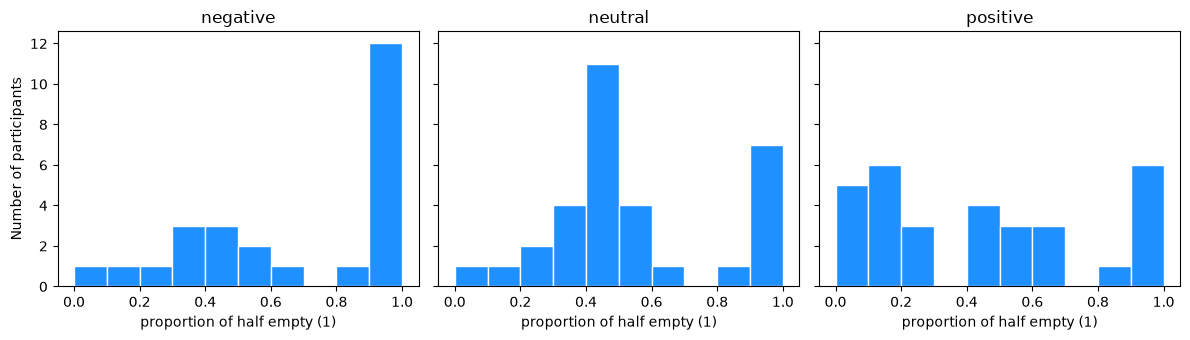

          人数   中央値  全部0  全部1
group                       
negative  25  0.80    1   11
neutral   32  0.45    0    6
positive  31  0.45    3    5

Kruskal-Wallis H=6.39, p=0.04097, ε²=0.073
negative vs neutral: p=0.1056, Holm補正後 p=0.2113
negative vs positive: p=0.01516, Holm補正後 p=0.04547
neutral vs positive: p=0.2627, Holm補正後 p=0.2627

χ²=62.44, Cramér's V=0.189, 並べ替え検定 p=0.0320


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency
from statsmodels.stats.multitest import multipletests

order = ["negative", "neutral", "positive"]

# ===== 1人1行の表(half empty = 1 の割合)=====
pt = df_fc.groupby("responseId").agg(
    group=("Message Group", "first"),
    n1=("frame_choice", "sum"),
    n=("frame_choice", "size"),
)
pt["n0"] = pt["n"] - pt["n1"]
pt["p1"] = pt["n1"] / pt["n"]

# ===== 1. 人ごとの割合の分布(群別)=====
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
bins = np.linspace(0, 1, 11)
for ax, g in zip(axes, order):
    ax.hist(pt.loc[pt["group"] == g, "p1"], bins=bins,
            color="#1e90ff", edgecolor="white")
    ax.set_title(g)
    ax.set_xlabel("proportion of half empty (1)")
axes[0].set_ylabel("Number of participants")
plt.tight_layout()
plt.show()

# 「全部同じ選択」の人の割合
summary = pt.groupby("group")["p1"].agg(
    人数="size",
    中央値="median",
    全部0=lambda s: (s == 0).sum(),
    全部1=lambda s: (s == 1).sum(),
).reindex(order)
print(summary)

# ===== 2. 人単位: Kruskal-Wallis + 事後検定(Holm)=====
groups = [pt.loc[pt["group"] == g, "p1"].values for g in order]
H, p_kw = kruskal(*groups)
N = len(pt)
eps2 = H * (N + 1) / (N**2 - 1)
print(f"\nKruskal-Wallis H={H:.2f}, p={p_kw:.4g}, ε²={eps2:.3f}")

pairs = list(combinations(order, 2))
raw = [mannwhitneyu(pt.loc[pt["group"] == a, "p1"],
                    pt.loc[pt["group"] == b, "p1"]).pvalue for a, b in pairs]
adj = multipletests(raw, method="holm")[1]
for (a, b), r, q in zip(pairs, raw, adj):
    print(f"{a} vs {b}: p={r:.4g}, Holm補正後 p={q:.4g}")

# ===== 3. 全体: カイ二乗統計量 + 人単位の並べ替え検定 =====
def chi2_of(groups_arr):
    t = np.array([[pt["n0"][groups_arr == g].sum(),
                   pt["n1"][groups_arr == g].sum()] for g in order])
    return chi2_contingency(t, correction=False)[0]

labels = pt["group"].to_numpy()
obs = chi2_of(labels)
rng = np.random.default_rng(0)
n_perm = 5000
perm = np.array([chi2_of(rng.permutation(labels)) for _ in range(n_perm)])
p_perm = (np.sum(perm >= obs) + 1) / (n_perm + 1)

ct = np.array([[pt["n0"][labels == g].sum(), pt["n1"][labels == g].sum()] for g in order])
V = np.sqrt(obs / (ct.sum() * (min(ct.shape) - 1)))
print(f"\nχ²={obs:.2f}, Cramér's V={V:.3f}, 並べ替え検定 p={p_perm:.4f}")

In [23]:
# 人のタイプ: 全部0 / 混在 / 全部1
types = ["all0", "mixed", "all1"]
pt["type"] = np.select([pt["p1"] == 0, pt["p1"] == 1], ["all0", "all1"], default="mixed")

tab = pd.crosstab(pt["group"], pt["type"]).reindex(index=order, columns=types, fill_value=0)
print(tab)

# 並べ替え検定(期待度数が小さいため)
type_arr = pt["type"].to_numpy()
def chi2_tab(groups_arr):
    t = pd.crosstab(groups_arr, type_arr).reindex(index=order, columns=types, fill_value=0)
    return chi2_contingency(t, correction=False)[0]

labels = pt["group"].to_numpy()
rng = np.random.default_rng(0)
obs3 = chi2_tab(labels)
perm3 = np.array([chi2_tab(rng.permutation(labels)) for _ in range(5000)])
p3 = (np.sum(perm3 >= obs3) + 1) / (5000 + 1)
print(f"人タイプ×群 χ²={obs3:.2f}, 並べ替え p={p3:.4f}")

# 感度分析: 「全部同じ」の人を除いた、混在タイプの人だけで比較
mixed = pt[pt["type"] == "mixed"]
H2, p2 = kruskal(*[mixed.loc[mixed["group"] == g, "p1"] for g in order])
print(f"混在タイプのみ Kruskal-Wallis H={H2:.2f}, p={p2:.4f}")

type      all0  mixed  all1
group                      
negative     1     13    11
neutral      0     26     6
positive     3     23     5
人タイプ×群 χ²=10.15, 並べ替え p=0.0322
混在タイプのみ Kruskal-Wallis H=0.93, p=0.6289


In [24]:
print(pt.groupby("group")["n"].describe())     # 群ごとの有効ブロック数の分布

          count       mean       std   min   25%   50%   75%   max
group                                                             
negative   25.0  19.880000  0.439697  18.0  20.0  20.0  20.0  20.0
neutral    32.0  19.843750  0.514899  18.0  20.0  20.0  20.0  20.0
positive   31.0  19.870968  0.340777  19.0  20.0  20.0  20.0  20.0


##### GEEなど

In [25]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from itertools import combinations
from statsmodels.stats.multitest import multipletests

order = ["negative", "neutral", "positive"]

# ブロック単位のデータ(df_fc は前に作ったもの)
d = df_fc.rename(columns={"Message Group": "group"}).copy()
d["group"] = pd.Categorical(d["group"], categories=order)   # negative が基準群
d["frame_choice"] = d["frame_choice"].astype(int)

# ===== GEE(ロジスティック、参加者内は交換可能な相関)=====
model = smf.gee(
    "frame_choice ~ C(group)",
    groups="responseId",
    data=d,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Exchangeable(),
)
res = model.fit()
print(res.summary())
print(res.cov_struct.summary())            # 推定された参加者内相関

# ===== 群全体の効果(3群まとめた Wald 検定)=====
print(res.wald_test_terms())

# ===== オッズ比(基準: negative)=====
ci = res.conf_int()
or_tab = pd.DataFrame({
    "OR": np.exp(res.params),
    "lower": np.exp(ci[0]),
    "upper": np.exp(ci[1]),
    "p": res.pvalues,
}).drop(index="Intercept")
print(or_tab.round(4))

# ===== 3つの対比較(Holm補正)=====
terms = {
    "neutral": "C(group)[T.neutral]",
    "positive": "C(group)[T.positive]",
}
rows = []
for a, b in combinations(order, 2):                 # a が基準側、b が比較側
    expr = f"{terms[b]} = 0" if a == "negative" else f"{terms[b]} - {terms[a]} = 0"
    tt = res.t_test(expr)
    est = float(np.squeeze(tt.effect))
    lo, hi = np.squeeze(tt.conf_int())
    rows.append({
        "contrast": f"{b} vs {a}",
        "OR": np.exp(est),
        "lower": np.exp(lo),
        "upper": np.exp(hi),
        "p": float(np.squeeze(tt.pvalue)),
    })
pw = pd.DataFrame(rows)
pw["p_holm"] = multipletests(pw["p"], method="holm")[1]
print(pw.round(4))

# ===== 群ごとの推定確率(half empty を選ぶ確率)=====
newd = pd.DataFrame({"group": pd.Categorical(order, categories=order)})
print(pd.Series(res.predict(newd), index=order).round(3))


# ===== 頑健性: 小標本補正した標準誤差 =====
res_br = model.fit(cov_type="bias_reduced")
print(res_br.wald_test_terms())
print(pd.DataFrame({"OR": np.exp(res_br.params), "p": res_br.pvalues}).round(4))

pred = pd.Series(np.asarray(res.predict(newd)), index=order)
print(pred.round(3))

                               GEE Regression Results                              
Dep. Variable:                frame_choice   No. Observations:                 1748
Model:                                 GEE   No. clusters:                       88
Method:                        Generalized   Min. cluster size:                  18
                      Estimating Equations   Max. cluster size:                  20
Family:                           Binomial   Mean cluster size:                19.9
Dependence structure:         Exchangeable   Num. iterations:                     4
Date:                     Mon, 05 Oct 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         17:29:04
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.7856      0.309      2.541      0.011  

##### test

In [26]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

order = ["negative", "neutral", "positive"]

d = df_fc.rename(columns={"Message Group": "group"}).copy()
d["frame_choice"] = d["frame_choice"].astype(int)
d["group"] = pd.Categorical(d["group"], categories=["neutral", "negative", "positive"])  # neutral が基準

m = smf.gee(
    "frame_choice ~ C(group)",
    groups="responseId", data=d,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Exchangeable(),
).fit()
print(m.summary())

# 切片 = neutral の half empty のロジット。0 との差の検定 = 50%との比較
print("neutral の確率:", 1 / (1 + np.exp(-m.params["Intercept"])))
print("切片のp値(neutral vs 50%):", m.pvalues["Intercept"])

# 統制群からの乖離(オッズ比)。補正は2つの比較に対して
keys = ["C(group)[T.negative]", "C(group)[T.positive]"]
ci = m.conf_int().loc[keys]
out = pd.DataFrame({
    "OR": np.exp(m.params[keys]),
    "lower": np.exp(ci[0]),
    "upper": np.exp(ci[1]),
    "p": m.pvalues[keys],
})
out["p_holm"] = multipletests(out["p"], method="holm")[1]
print(out.round(4))

                               GEE Regression Results                              
Dep. Variable:                frame_choice   No. Observations:                 1748
Model:                                 GEE   No. clusters:                       88
Method:                        Generalized   Min. cluster size:                  18
                      Estimating Equations   Max. cluster size:                  20
Family:                           Binomial   Mean cluster size:                19.9
Dependence structure:         Exchangeable   Num. iterations:                     4
Date:                     Mon, 05 Oct 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         17:38:15
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.1675      0.198      0.845      0.398  